In [21]:
import json
import pandas as pd
import networkx as nx
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%pip install powerlaw
import powerlaw
import os
from itertools import combinations
import random

Note: you may need to restart the kernel to use updated packages.


In [22]:
def top_text_pref_prop(df):
    prop_mentions = df.loc[df["prop"] == "PROP", "text"]
    if len(prop_mentions) > 0:
        return prop_mentions.value_counts().idxmax()
    return df["text"].value_counts().idxmax()

def load_entities_with_fix(BASE_DIR):
    """
    Load entities, automatically fixing first-person narration issues.
    """
    FIXED_FILE = f"{BASE_DIR}.entities.fixed"
    ENT_FILE = f"{BASE_DIR}.entities"
    
    # If fixed file exists, use it
    if os.path.exists(FIXED_FILE):
        return pd.read_csv(FIXED_FILE, sep="\t", quoting=3)
    
    # Otherwise, load original and check if fix needed
    ents = pd.read_csv(ENT_FILE, sep="\t", quoting=3)
    ents_persons = ents[ents["cat"] == "PER"].copy()
    
    # Quick check: are there orphaned first-person pronouns?
    first_person = ents_persons[ents_persons["text"].str.lower().isin(['i', 'me', 'my', 'mine', 'myself'])]
    
    if len(first_person) > 100:  # Likely first-person novel
        # Find orphaned clusters (first-person but no proper nouns)
        orphaned = []
        for cluster_id in first_person["COREF"].value_counts().head(5).index:
            cluster = ents_persons[ents_persons["COREF"].astype(str) == str(cluster_id)]
            if (cluster["prop"] == "PROP").sum() == 0:
                orphaned.append((cluster_id, len(cluster)))
        
        if orphaned:
            print(f"\n  Detected first-person narration issue in {os.path.basename(BASE_DIR)}")
            print(f"   Found {len(orphaned)} orphaned pronoun clusters")
            
            # Find protagonist by looking for character with BOTH:
            # 1. Proper nouns (is a named character)
            # 2. Second-person pronouns
            
            ents_persons["COREF"] = ents_persons["COREF"].astype(str)
            
            # Count second-person pronouns per cluster
            second_person = ents_persons[ents_persons["text"].str.lower().isin(['you', 'your', 'yours', 'yourself'])]
            second_person_counts = second_person.groupby("COREF").size()
            
            # Get clusters with proper nouns
            cluster_stats = (
                ents_persons.groupby("COREF")
                .agg({
                    "text": "count",
                    "prop": lambda x: (x == "PROP").sum()
                })
                .rename(columns={"text": "n_mentions", "prop": "n_prop"})
            )
            
            # Add second-person counts
            cluster_stats["n_second_person"] = cluster_stats.index.map(
                lambda x: second_person_counts.get(x, 0)
            )
            
            # Protagonist = most second-person pronouns among named characters
            candidates = cluster_stats[cluster_stats["n_prop"] > 0].copy()
            protagonist = candidates.sort_values("n_second_person", ascending=False).index[0]
            
            # Get protagonist name
            protag_cluster = ents_persons[ents_persons["COREF"] == protagonist]
            protag_name = protag_cluster[protag_cluster["prop"] == "PROP"]["text"].value_counts().index[0]
            
            print(f"   Detected protagonist: Cluster {protagonist} ({protag_name})")
            print(f"   ({candidates.loc[protagonist, 'n_second_person']} 'you' pronouns)")
            
            # Fix the data
            ents_fixed = ents.copy()
            ents_fixed["COREF"] = ents_fixed["COREF"].astype(str)
            total_merged = 0
            for cluster_id, count in orphaned:
                ents_fixed.loc[ents_fixed["COREF"] == str(cluster_id), "COREF"] = protagonist
                total_merged += count
                print(f"   Merged {count} mentions from cluster {cluster_id}")
            
            # Save fixed file
            ents_fixed.to_csv(FIXED_FILE, sep="\t", index=False, quoting=3)
            
            before = len(ents_persons[ents_persons["COREF"] == protagonist])
            after = len(ents_fixed[ents_fixed["COREF"].astype(str) == protagonist])
            print(f"    {protag_name}: {before} → {after} mentions (+{after-before})")
            print(f"    Saved fixed entities to {FIXED_FILE}\n")
            
            return ents_fixed
    
    # No fix needed
    return ents

def load_character_network(BASE_DIR, network_type='named'):
    """
    Load character network from BookNLP output.
    """
    if network_type == 'named':
        CHAR_FILE = f"{BASE_DIR}.characters.json"
        with open(CHAR_FILE, "r") as f:
            data = json.load(f)
        id2name = {
            str(char["character_id"]): char["canonical_name"].title()
            for char in data["characters"]
        }
        ENT_FILE = f"{BASE_DIR}.entities"
        TOK_FILE = f"{BASE_DIR}.tokens"
        ents = load_entities_with_fix(BASE_DIR)
        mask = (ents["cat"] == "PER") & (ents["prop"] == "PROP")
        pers = ents[mask].copy()
        pers["COREF"] = pers["COREF"].astype(str)
        pers["character"] = pers["COREF"].map(id2name)
        pers = pers.dropna(subset=["character"])
    else:
        # For total network
        ENT_FILE = f"{BASE_DIR}.entities"
        TOK_FILE = f"{BASE_DIR}.tokens"
        ents = load_entities_with_fix(BASE_DIR)
        ents = ents[ents["cat"] == "PER"].copy()
        ents["COREF"] = ents["COREF"].astype(str)

        cluster_summary = (
            ents.groupby("COREF")
            .apply(lambda df: pd.Series({
                "n_prop": (df["prop"] == "PROP").sum(),
                "top_text": top_text_pref_prop(df)
            }), include_groups=False)
            .reset_index()
        )
        clean_clusters = cluster_summary[cluster_summary["n_prop"] > 0].copy()
        coref_to_name = dict(zip(clean_clusters["COREF"], clean_clusters["top_text"]))
        ents["character"] = ents["COREF"].map(coref_to_name)
        pers = ents.dropna(subset=["character"])
    
    # Merge with tokens to get paragraph IDs
    tokens = pd.read_csv(TOK_FILE, sep="\t", quoting=3)
    pers = pers.merge(
        tokens[["token_ID_within_document", "paragraph_ID"]],
        left_on="start_token",
        right_on="token_ID_within_document",
        how="left"
    )
    
    # Build co-occurrence network
    cooccur = Counter()
    for _, group in pers.groupby("paragraph_ID"):
        chars = sorted(group["character"].unique())
        for i in range(len(chars)):
            for j in range(i+1, len(chars)):
                cooccur[(chars[i], chars[j])] += 1
    
    # Create graph
    G = nx.Graph()
    for (a, b), w in cooccur.items():
        G.add_edge(a, b, weight=w)
    
    # Store character frequencies as node attributes
    freq = pers["character"].value_counts().to_dict()
    nx.set_node_attributes(G, freq, 'frequency')
    
    return G


def analyze_degree_distribution(G, title="", plot=True):
    """
    Analyze degree distribution to check for scale-free property.
    """
    degrees = [d for n, d in G.degree()]
    
    # Fit power law
    fit = powerlaw.Fit(degrees, discrete=True, xmin=1)
    
    results = {
        'alpha': fit.power_law.alpha,
        'xmin': fit.power_law.xmin,
        'sigma': fit.power_law.sigma,
        'R': fit.power_law.KS(),  # KS distance
        'p_value': fit.distribution_compare('power_law', 'exponential')[1]
    }
    
    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Degree distribution
        ax = axes[0]
        degree_counts = Counter(degrees)
        x, y = zip(*sorted(degree_counts.items()))
        ax.loglog(x, y, 'bo', alpha=0.6, markersize=8)
        ax.set_xlabel('Degree (k)', fontsize=12)
        ax.set_ylabel('Count', fontsize=12)
        ax.set_title(f'{title} Degree Distribution (log-log)', fontsize=14)
        ax.grid(True, alpha=0.3)
        
        # Power law fit
        ax = axes[1]
        fit.power_law.plot_pdf(ax=ax, color='b', linewidth=2, label='Data')
        fit.power_law.plot_pdf(ax=ax, color='r', linestyle='--', 
                                label=rf'Power law fit ($\alpha$={fit.power_law.alpha:.2f})')
        ax.set_xlabel('Degree', fontsize=12)
        ax.set_ylabel('P(X ≥ x)', fontsize=12)
        ax.set_title(f'{title} Power Law Fit', fontsize=14)
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f'degree_distribution_{title.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    return results


def compute_delta_hyperbolicity(G, sample_size=None):
    """
    Compute delta-hyperbolicity (Gromov hyperbolicity) of the graph.
    
    Lower values indicate more tree-like/hyperbolic structure.
    """
    if not nx.is_connected(G):
        # Use largest connected component
        G = G.subgraph(max(nx.connected_components(G), key=len)).copy()
    
    # Compute all shortest paths
    spl = dict(nx.all_pairs_shortest_path_length(G))
    
    nodes = list(G.nodes())
    n = len(nodes)
    
    if sample_size is None or sample_size >= n**4:
        sample = list(combinations(nodes, 4))
    else:
        sample = [tuple(random.sample(nodes, 4)) for _ in range(sample_size)]
    
    deltas = []
    for (a, b, c, d) in sample:
        # Six distances for four points
        try:
            dists = [
                spl[a][b] + spl[c][d],
                spl[a][c] + spl[b][d],
                spl[a][d] + spl[b][c]
            ]
            dists.sort()
            # for this quadruple
            delta = (dists[2] - dists[1]) / 2
            deltas.append(delta)
        except KeyError:
            continue
    
    return np.max(deltas) if deltas else None


def compute_hierarchy_metrics(G):
    """
    Compute various hierarchy metrics for the network.
    """
    if not nx.is_connected(G):
        G = G.subgraph(max(nx.connected_components(G), key=len)).copy()
    
    # Gini coefficient of degree distribution
    degrees = sorted([d for n, d in G.degree()])
    n = len(degrees)
    gini = (2 * sum((i+1) * d for i, d in enumerate(degrees))) / (n * sum(degrees)) - (n+1)/n
    
    # Centralization (degree)
    max_degree = max(degrees)
    n_nodes = len(G)
    centralization = sum(max_degree - d for d in degrees) / ((n_nodes - 1) * (n_nodes - 2))
    
    # Average clustering coefficient
    avg_clustering = nx.average_clustering(G)
    
    # Assortativity (degree correlation)
    try:
        assortativity = nx.degree_assortativity_coefficient(G)
    except:
        assortativity = None
    
    # Diameter and average path length
    try:
        diameter = nx.diameter(G)
        avg_path_length = nx.average_shortest_path_length(G)
    except:
        diameter = None
        avg_path_length = None
    
    return {
        'gini_coefficient': gini,
        'degree_centralization': centralization,
        'avg_clustering': avg_clustering,
        'assortativity': assortativity,
        'diameter': diameter,
        'avg_path_length': avg_path_length,
        'num_nodes': len(G),
        'num_edges': G.number_of_edges(),
        'density': nx.density(G)
    }


def compute_centrality_measures(G):
    """
    Compute various centrality measures for character importance.
    """
    centralities = pd.DataFrame({
        'character': list(G.nodes()),
        'degree': dict(G.degree()).values(),
        'betweenness': nx.betweenness_centrality(G).values(),
        'closeness': nx.closeness_centrality(G).values(),
        'eigenvector': nx.eigenvector_centrality(G, max_iter=1000).values(),
        'pagerank': nx.pagerank(G).values()
    })
    
    # Add frequency if available
    if 'frequency' in G.nodes[list(G.nodes())[0]]:
        centralities['frequency'] = [G.nodes[n]['frequency'] for n in G.nodes()]
    
    return centralities.sort_values('degree', ascending=False)


def full_network_analysis(BASE_DIR, title="Novel", save_prefix=""):
    """
    Complete network analysis pipeline.
    """
    print(f"\n{'='*60}")
    print(f"Analyzing: {title}")
    print(f"{'='*60}\n")
    
    # Load network
    print("Loading network...")
    G = load_character_network(BASE_DIR, network_type='total')
    
    # Basic stats
    print(f"Network size: {len(G)} nodes, {G.number_of_edges()} edges")
    print(f"Density: {nx.density(G):.4f}")
    
    # # Degree distribution and power law fit
    # print("\nAnalyzing degree distribution...")
    # degree_results = analyze_degree_distribution(G, title=title)
    # print(f"Power law exponent (alpha): {degree_results['alpha']:.3f}")
    # print(f"KS statistic: {degree_results['R']:.4f}")
    # print(f"Power law vs exponential p-value: {degree_results['p_value']:.4f}")
    
    # Hyperbolicity
    print("\nComputing delta-hyperbolicity...")
    sample_size = len(G)**4  # Sample for large graphs
    delta = compute_delta_hyperbolicity(G, sample_size=sample_size)
    print(f"delta-hyperbolicity: {delta:.3f}")
    
    # Hierarchy metrics
    print("\nComputing hierarchy metrics...")
    hierarchy = compute_hierarchy_metrics(G)
    print(f"Gini coefficient: {hierarchy['gini_coefficient']:.3f}")
    print(f"Degree centralization: {hierarchy['degree_centralization']:.3f}")
    print(f"Average clustering: {hierarchy['avg_clustering']:.3f}")
    print(f"Assortativity: {hierarchy['assortativity']:.3f}" if hierarchy['assortativity'] else "Assortativity: N/A")
    
    # Centrality measures
    print("\nComputing centrality measures...")
    centralities = compute_centrality_measures(G)
    print("\nTop 10 characters by degree:")
    print(centralities.head(10)[['character', 'degree', 'betweenness', 'pagerank']])
    
    # Save results
    results = {
        'graph': G,
        'hyperbolicity': delta,
        'hierarchy': hierarchy,
        'centralities': centralities
    }
    
    if save_prefix:
        # Save network as edgelist
        nx.write_weighted_edgelist(G, f'{save_prefix}_network.edgelist')
        
        # Save centralities
        centralities.to_csv(f'{save_prefix}_centralities.csv', index=False)
        
        # Save summary stats
        summary = {
            'hyperbolicity': delta,
            **hierarchy
        }
        with open(f'{save_prefix}_summary.json', 'w') as f:
            json.dump(summary, f, indent=2)
        
        print(f"\nResults saved with prefix: {save_prefix}")
    
    return results


def compare_novels(novel_configs):
    """
    Compare structural properties across multiple novels.
    """
    results = []
    
    for base_dir, title, save_prefix in novel_configs:
        analysis = full_network_analysis(base_dir, title, save_prefix)
        
        summary = {
            'novel': title,
            'n_nodes': analysis['hierarchy']['num_nodes'],
            'n_edges': analysis['hierarchy']['num_edges'],
            'density': analysis['hierarchy']['density'],
            'hyperbolicity': analysis['hyperbolicity'],
            'gini': analysis['hierarchy']['gini_coefficient'],
            'centralization': analysis['hierarchy']['degree_centralization'],
            'clustering': analysis['hierarchy']['avg_clustering'],
            'assortativity': analysis['hierarchy']['assortativity']
        }
        results.append(summary)
    
    df = pd.DataFrame(results)
    
    # Create comparison plot
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Hyperbolicity
    ax = axes[0, 1]
    ax.bar(df['novel'], df['hyperbolicity'], color='coral')
    ax.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label=rf'$\delta$=1 threshold')
    ax.set_ylabel(rf'$\delta$-hyperbolicity', fontsize=11)
    ax.set_title('Tree-likeness', fontsize=12)
    ax.legend()
    ax.tick_params(axis='x', rotation=45)
    
    # Gini coefficient
    ax = axes[1, 0]
    ax.bar(df['novel'], df['gini'], color='seagreen')
    ax.set_ylabel('Gini Coefficient', fontsize=11)
    ax.set_title('Degree Inequality', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    
    # Clustering vs Density
    ax = axes[1, 1]
    ax.scatter(df['density'], df['clustering'], s=100, alpha=0.6)
    for i, txt in enumerate(df['novel']):
        ax.annotate(txt, (df['density'].iloc[i], df['clustering'].iloc[i]),
                   fontsize=9, ha='center')
    ax.set_xlabel('Density', fontsize=11)
    ax.set_ylabel('Clustering', fontsize=11)
    ax.set_title('Network Structure', fontsize=12)
    
    plt.tight_layout()
    plt.savefig('novel_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return df


Analyzing: Jane Eyre

Loading network...
Network size: 314 nodes, 1105 edges
Density: 0.0225

Analyzing degree distribution...


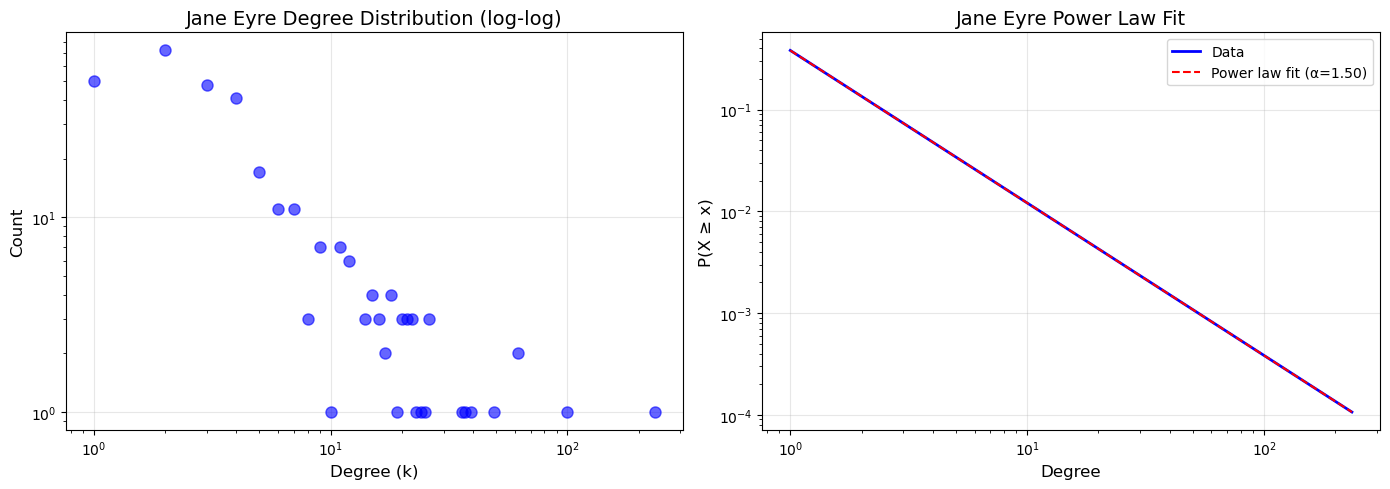

Power law exponent (alpha): 1.500
KS statistic: 0.2235
Power law vs exponential p-value: 0.6699

Computing delta-hyperbolicity...
delta-hyperbolicity: 1.000

Computing hierarchy metrics...
Gini coefficient: 0.601
Degree centralization: 0.738
Average clustering: 0.716
Assortativity: -0.255

Computing centrality measures...

Top 10 characters by degree:
         character  degree  betweenness  pagerank
1             Jane     235     0.692420  0.219430
105  Mr. Rochester     100     0.152418  0.079679
61        St. John      62     0.086939  0.047609
33    Mrs. Fairfax      62     0.050682  0.038952
8           Bessie      49     0.032585  0.030687
143    Miss Ingram      39     0.031438  0.018076
112          Adèle      37     0.011032  0.022514
15       Mrs. Reed      36     0.015460  0.017629
152         Louisa      26     0.004917  0.007282
138   Colonel Dent      26     0.007992  0.009263

Results saved with prefix: jane_eyre


In [3]:
# Single novel analysis
BASE_DIR = "../jane/jane_eyre"
results = full_network_analysis(BASE_DIR, title="Jane Eyre", save_prefix="jane_eyre")


Analyzing: Jane Eyre

Loading network...
Network size: 314 nodes, 1105 edges
Density: 0.0225

Computing delta-hyperbolicity...
delta-hyperbolicity: 1.000

Computing hierarchy metrics...
Gini coefficient: 0.601
Degree centralization: 0.738
Average clustering: 0.716
Assortativity: -0.255

Computing centrality measures...

Top 10 characters by degree:
         character  degree  betweenness  pagerank
1             Jane     235     0.692420  0.219430
105  Mr. Rochester     100     0.152418  0.079679
61        St. John      62     0.086939  0.047609
33    Mrs. Fairfax      62     0.050682  0.038952
8           Bessie      49     0.032585  0.030687
143    Miss Ingram      39     0.031438  0.018076
112          Adèle      37     0.011032  0.022514
15       Mrs. Reed      36     0.015460  0.017629
152         Louisa      26     0.004917  0.007282
138   Colonel Dent      26     0.007992  0.009263

Results saved with prefix: jane_eyre

Analyzing: Pride and Prejudice

Loading network...
Network 

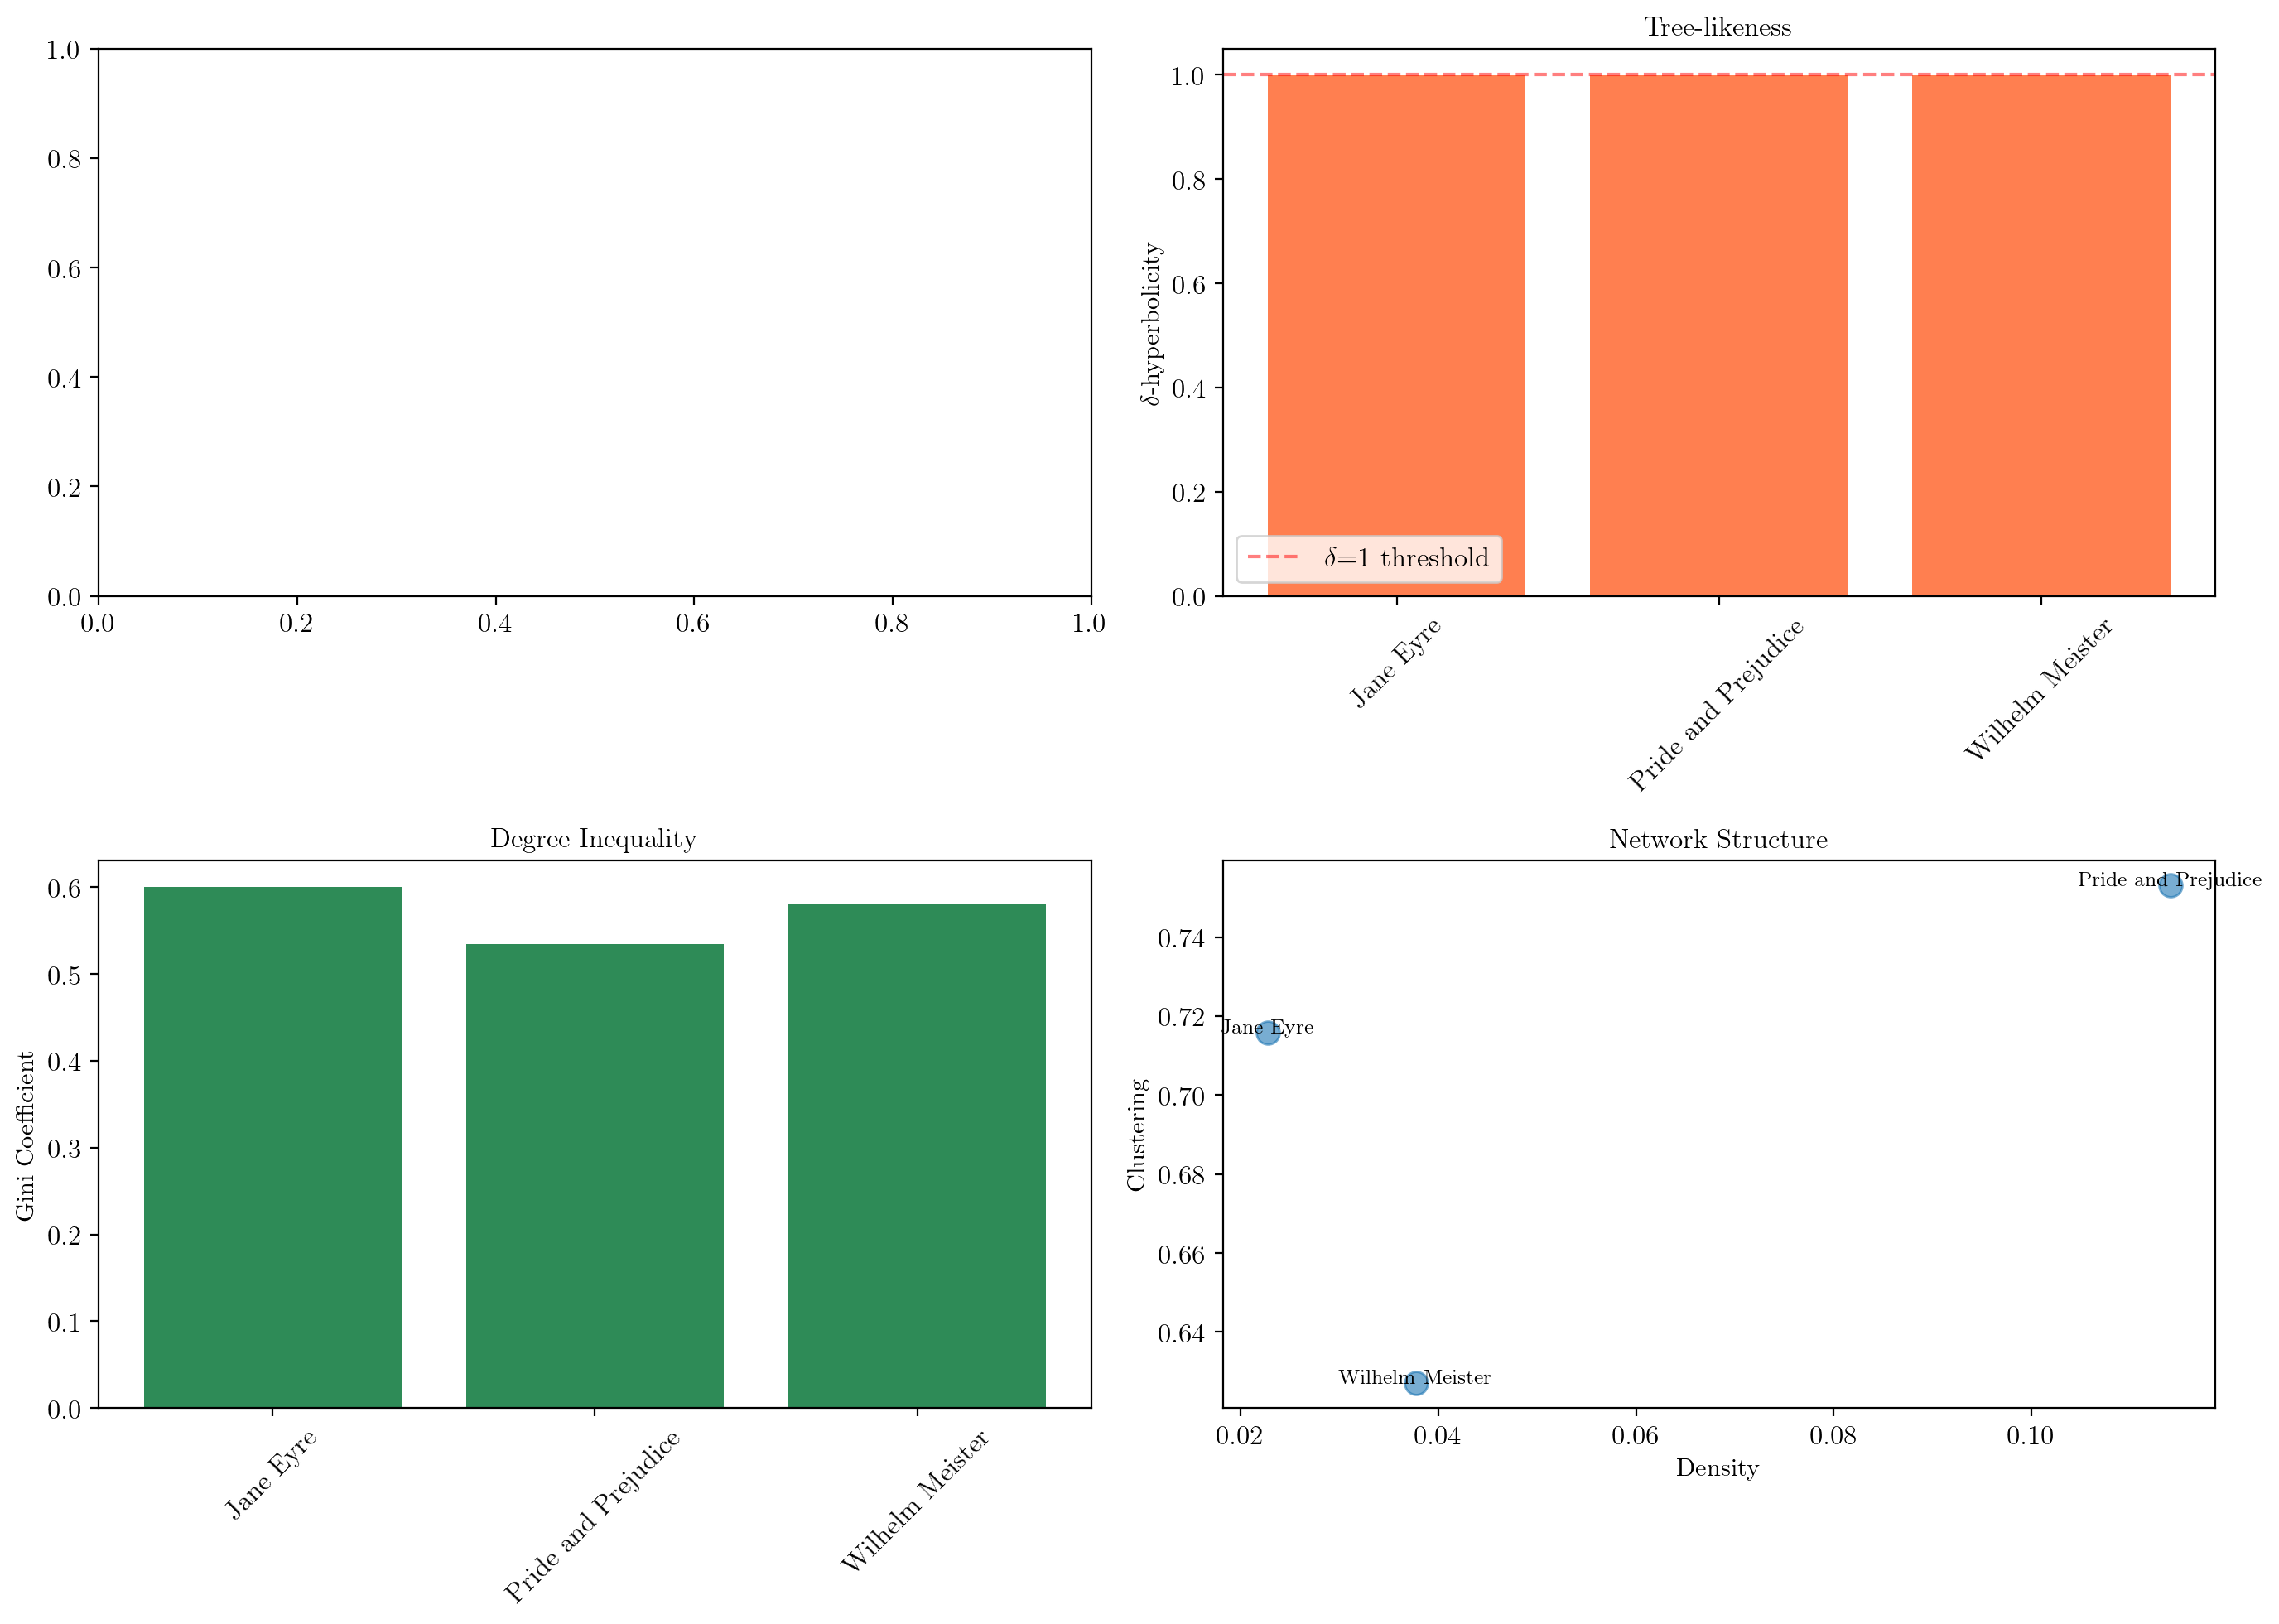



Comparison Summary:
                 novel  n_nodes  n_edges   density  hyperbolicity      gini  centralization  clustering  assortativity
0            Jane Eyre      312     1104  0.022755            1.0  0.600520        0.737600    0.715861      -0.255332
1  Pride and Prejudice      126      898  0.114032            1.0  0.534848        0.672645    0.753057      -0.368676
2      Wilhelm Meister      168      529  0.037710            1.0  0.579924        0.695116    0.627080      -0.278686


In [23]:
# Compare multiple novels
novels = [
    ("../jane/jane_eyre", "Jane Eyre", "jane_eyre"),
    ("../results/output/pride", "Pride and Prejudice", "pride_prejudice"),
    ("../wilhelm/wilhelm_meisters", "Wilhelm Meister", "wilhelm_meister")
]

comparison = compare_novels(novels)
comparison.to_csv('novel_comparison.csv', index=False)
print("\n\nComparison Summary:")
print(comparison.to_string())

In [16]:
G = load_character_network("../jane/jane_eyre", network_type='total')

for n_samples in [10000000]:
    delta = compute_delta_hyperbolicity(G, sample_size=n_samples)
    print(f"n={n_samples:5d}: δ = {delta:.4f}")

/tmp/ipykernel_2639432/4207970462.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: pd.Series({


n=10000000: δ = 1.5000


In [15]:
G = load_character_network("../results/output/pride", network_type='total')

for n_samples in [10000000]:
    delta = compute_delta_hyperbolicity(G, sample_size=n_samples)
    print(f"n={n_samples:5d}: δ = {delta:.4f}")

/tmp/ipykernel_2639432/4207970462.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: pd.Series({


n=10000000: δ = 1.0000


In [17]:
G = load_character_network("../wilhelm/wilhelm_meisters", network_type='total')

for n_samples in [10000000]:
    delta = compute_delta_hyperbolicity(G, sample_size=n_samples)
    print(f"n={n_samples:5d}: δ = {delta:.4f}")

/tmp/ipykernel_2639432/4207970462.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: pd.Series({


n=10000000: δ = 1.0000


In [25]:
BASE_DIR = "../jane/jane_eyre"
ENT_FILE = f"{BASE_DIR}.entities"
ents = pd.read_csv(ENT_FILE, sep="\t", quoting=3)
ents = ents[ents["cat"] == "PER"].copy()

# Look at cluster 141 (Jane's cluster)
jane_cluster = ents[ents["COREF"].astype(str) == "141"]

print(f"Cluster 141 (Jane) - Total mentions: {len(jane_cluster)}")
print("\nMention type breakdown:")
print(jane_cluster["prop"].value_counts())

print("\nMost common texts in Jane's cluster:")
print(jane_cluster["text"].value_counts().head(20))

# Check specifically for first-person pronouns
first_person_in_jane = jane_cluster[jane_cluster["text"].str.lower().isin(['i', 'me', 'my', 'mine', 'myself'])]
print(f"\n\nFirst-person pronouns in Jane's cluster: {len(first_person_in_jane)}")
if len(first_person_in_jane) > 0:
    print(first_person_in_jane["text"].value_counts())
else:
    print("❌ NO FIRST-PERSON PRONOUNS LINKED TO JANE!")
    
# Now check: where ARE the first-person pronouns?
print("\n" + "="*60)
print("WHERE ARE THE FIRST-PERSON PRONOUNS?")
print("="*60)

first_person_all = ents[ents["text"].str.lower().isin(['i', 'me', 'my', 'mine', 'myself'])]
print(f"\nTotal first-person pronouns in entire text: {len(first_person_all)}")

if len(first_person_all) > 0:
    print("\nTop clusters containing first-person pronouns:")
    for cluster_id, count in first_person_all["COREF"].value_counts().head(10).items():
        cluster_mentions = ents[ents["COREF"] == cluster_id]
        # What proper nouns are in this cluster?
        prop_nouns = cluster_mentions[cluster_mentions["prop"] == "PROP"]["text"].value_counts()
        print(f"\n  Cluster {cluster_id}: {count} first-person pronouns")
        print(f"    Total mentions: {len(cluster_mentions)}")
        print(f"    Proper nouns: {dict(prop_nouns.head(3))}")

Cluster 141 (Jane) - Total mentions: 787

Mention type breakdown:
prop
PRON    454
PROP    333
Name: count, dtype: int64

Most common texts in Jane's cluster:
text
you                 284
Jane                232
your                 70
Miss Eyre            42
Jane Eyre            34
her                  30
You                  26
she                  21
Miss Jane            12
yourself              9
Your                  5
Eyre                  5
yours                 3
She                   2
JANE EYRE             2
a Miss Eyre           1
dear Jane             1
ye                    1
cousin Jane Eyre      1
I                     1
Name: count, dtype: int64


First-person pronouns in Jane's cluster: 2
text
I     1
my    1
Name: count, dtype: int64

WHERE ARE THE FIRST-PERSON PRONOUNS?

Total first-person pronouns in entire text: 11713

Top clusters containing first-person pronouns:

  Cluster 0: 7756 first-person pronouns
    Total mentions: 9132
    Proper nouns: {}

  Cluster 288


POWER LAW FIT DIAGNOSTICS: Jane Eyre (Fixed)

powerlaw library fit:
  alpha = 1.498
  xmin = 1.0
  KS distance = 0.2276

Manual log-log regression:
  alpha = 1.013
  R-squared = 0.7270
  p-value = 0.000000

Model comparison (powerlaw library):
  Power law vs Exponential:
    Log-likelihood ratio: -16.233
    p-value: 0.621613
    → Cannot distinguish (p > 0.05)


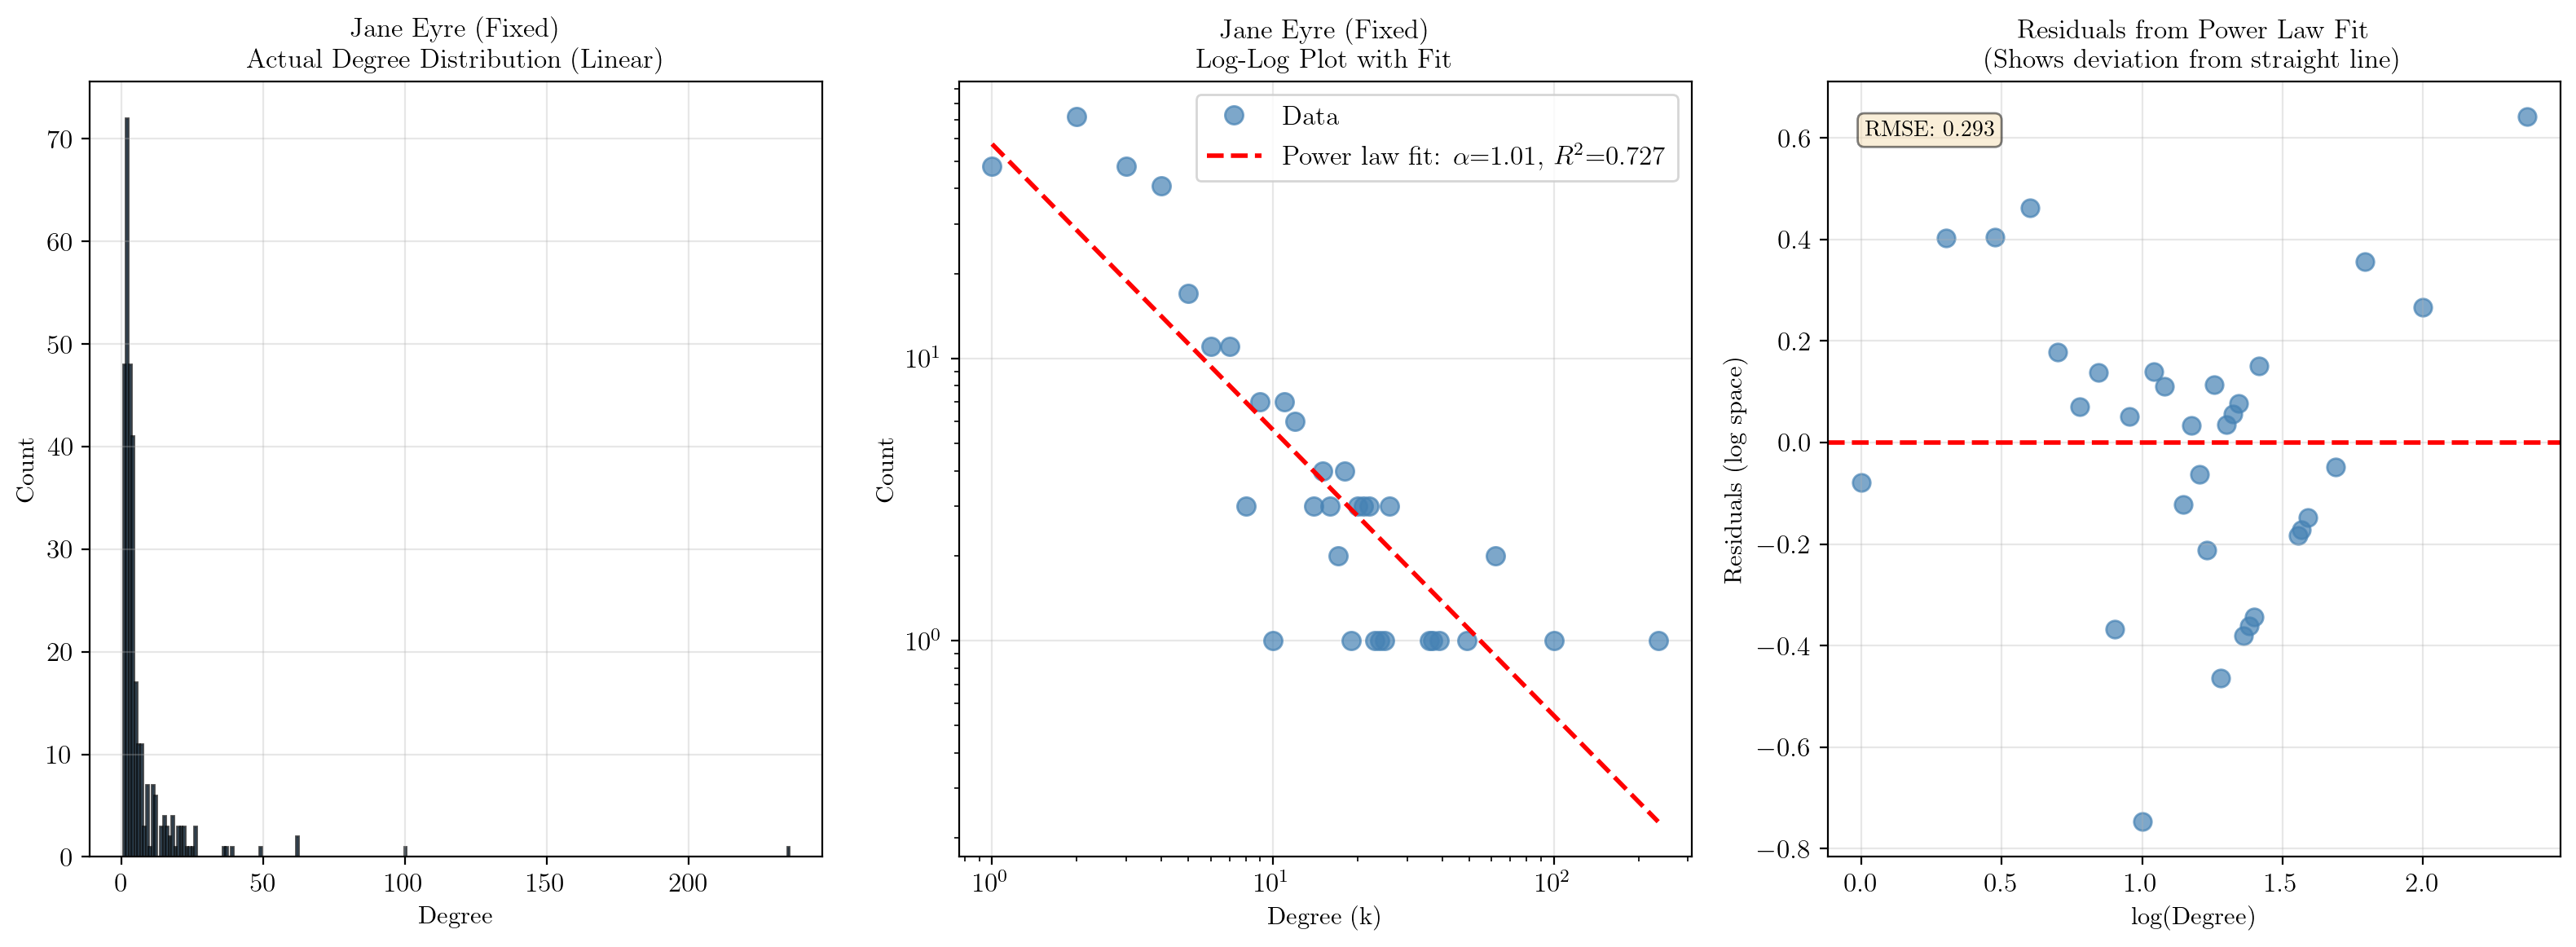

In [16]:
import matplotlib as mpl

mpl.rcParams.update({
    "text.usetex": True,                
    "font.family": "serif",     
    "font.serif": ["Computer Modern"],  
    "axes.labelsize": 14,
    "font.size": 13,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.dpi": 200,
    "savefig.dpi": 300,
    "axes.titlesize": 14,
    "text.latex.preamble": r"\usepackage{amsmath,amssymb}",
})

def power_law_analysis(G, title=""):
    degrees = [d for n, d in G.degree()]
    
    # Fit using powerlaw library
    fit = powerlaw.Fit(degrees, discrete=True, xmin=1)
    
    # Get actual degree counts
    degree_counts = Counter(degrees)
    x = np.array(sorted(degree_counts.keys()))
    y = np.array([degree_counts[k] for k in x])
    
    # Manual power law fit in log-log space
    mask = (x > 0) & (y > 0)
    log_x = np.log10(x[mask])
    log_y = np.log10(y[mask])
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(log_x, log_y)
    alpha_manual = -slope
    r_squared = r_value**2
    
    print(f"\n{'='*60}")
    print(f"POWER LAW FIT DIAGNOSTICS: {title}")
    print(f"{'='*60}")
    print(f"\npowerlaw library fit:")
    print(f"  alpha = {fit.power_law.alpha:.3f}")
    print(f"  xmin = {fit.power_law.xmin}")
    print(f"  KS distance = {fit.power_law.KS():.4f}")
    
    print(f"\nManual log-log regression:")
    print(f"  alpha = {alpha_manual:.3f}")
    print(f"  R-squared = {r_squared:.4f}")
    print(f"  p-value = {p_value:.6f}")

    
    # Compare to other distributions
    print(f"\nModel comparison (powerlaw library):")
    try:
        R_exp, p_exp = fit.distribution_compare('power_law', 'exponential')
        print(f"  Power law vs Exponential:")
        print(f"    Log-likelihood ratio: {R_exp:.3f}")
        print(f"    p-value: {p_exp:.6f}")
        if p_exp < 0.05:
            if R_exp > 0:
                print(f"    → Power law significantly better")
            else:
                print(f"    → Exponential significantly better")
        else:
            print(f"    → Cannot distinguish (p > 0.05)")
    except:
        print(f"  (Comparison failed)")
    
    # Create diagnostic plots
    fig, axes = plt.subplots(1, 3, figsize=(16, 6))
    
    # Plot 1: Linear-linear (shows the actual distribution)
    ax = axes[0]
    ax.bar(x, y, color='steelblue', alpha=0.7, edgecolor='black')
    ax.set_xlabel('Degree', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'{title}\nActual Degree Distribution (Linear)', fontsize=12)
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Log-log with fit line
    ax = axes[1]
    ax.loglog(x, y, 'o', color='steelblue', markersize=8, alpha=0.7, label='Data')
    
    # Add manual fit line
    x_fit = np.logspace(np.log10(min(x[mask])), np.log10(max(x[mask])), 100)
    y_fit = 10**intercept * x_fit**(-alpha_manual)
    ax.loglog(x_fit, y_fit, 'r--', linewidth=2, 
             label=rf'Power law fit: $\alpha$={alpha_manual:.2f}, $R^2$={r_squared:.3f}')
    
    ax.set_xlabel('Degree (k)', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'{title}\nLog-Log Plot with Fit', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 3: Residuals (THIS SHOWS THE TRUTH)
    ax = axes[2]
    y_pred = 10**intercept * x[mask]**(-alpha_manual)
    residuals = log_y - np.log10(y_pred)
    ax.scatter(log_x, residuals, color='steelblue', alpha=0.7, s=60)
    ax.axhline(0, color='r', linestyle='--', linewidth=2)
    ax.set_xlabel('log(Degree)', fontsize=11)
    ax.set_ylabel('Residuals (log space)', fontsize=11)
    ax.set_title('Residuals from Power Law Fit\n(Shows deviation from straight line)', fontsize=12)
    ax.grid(True, alpha=0.3)
    
    # Add residual statistics
    rmse = np.sqrt(np.mean(residuals**2))
    ax.text(0.05, 0.95, f'RMSE: {rmse:.3f}', 
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}_power_law.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n{'='*60}\n")
    
    return {
        'alpha_powerlaw': fit.power_law.alpha,
        'alpha_manual': alpha_manual,
        'r_squared': r_squared,
        'ks_distance': fit.power_law.KS()
    }

# Test on Jane Eyre
G = load_character_network("../jane/jane_eyre", network_type='total')

# Keep only largest connected component
if not nx.is_connected(G):
    largest_cc = max(nx.connected_components(G), key=len)
    G = G.subgraph(largest_cc).copy()

results = power_law_analysis(G, "Jane Eyre (Fixed)")


  Detected first-person narration issue in wilhelm_meisters
   Found 1 orphaned pronoun clusters
   Detected protagonist: Cluster 234 (Wilhelm)
   (237 'you' pronouns)
   Merged 1662 mentions from cluster 0
    Wilhelm: 4497 → 6159 mentions (+1662)
    Saved fixed entities to ../wilhelm/wilhelm_meisters.entities.fixed


POWER LAW FIT DIAGNOSTICS: Wilhelm Meister's Apprenticeship

powerlaw library fit:
  alpha = 1.516
  xmin = 1.0
  KS distance = 0.1779

Manual log-log regression:
  alpha = 1.047
  R-squared = 0.8194
  p-value = 0.000000

Model comparison (powerlaw library):
  Power law vs Exponential:
    Log-likelihood ratio: -10.870
    p-value: 0.534717
    → Cannot distinguish (p > 0.05)


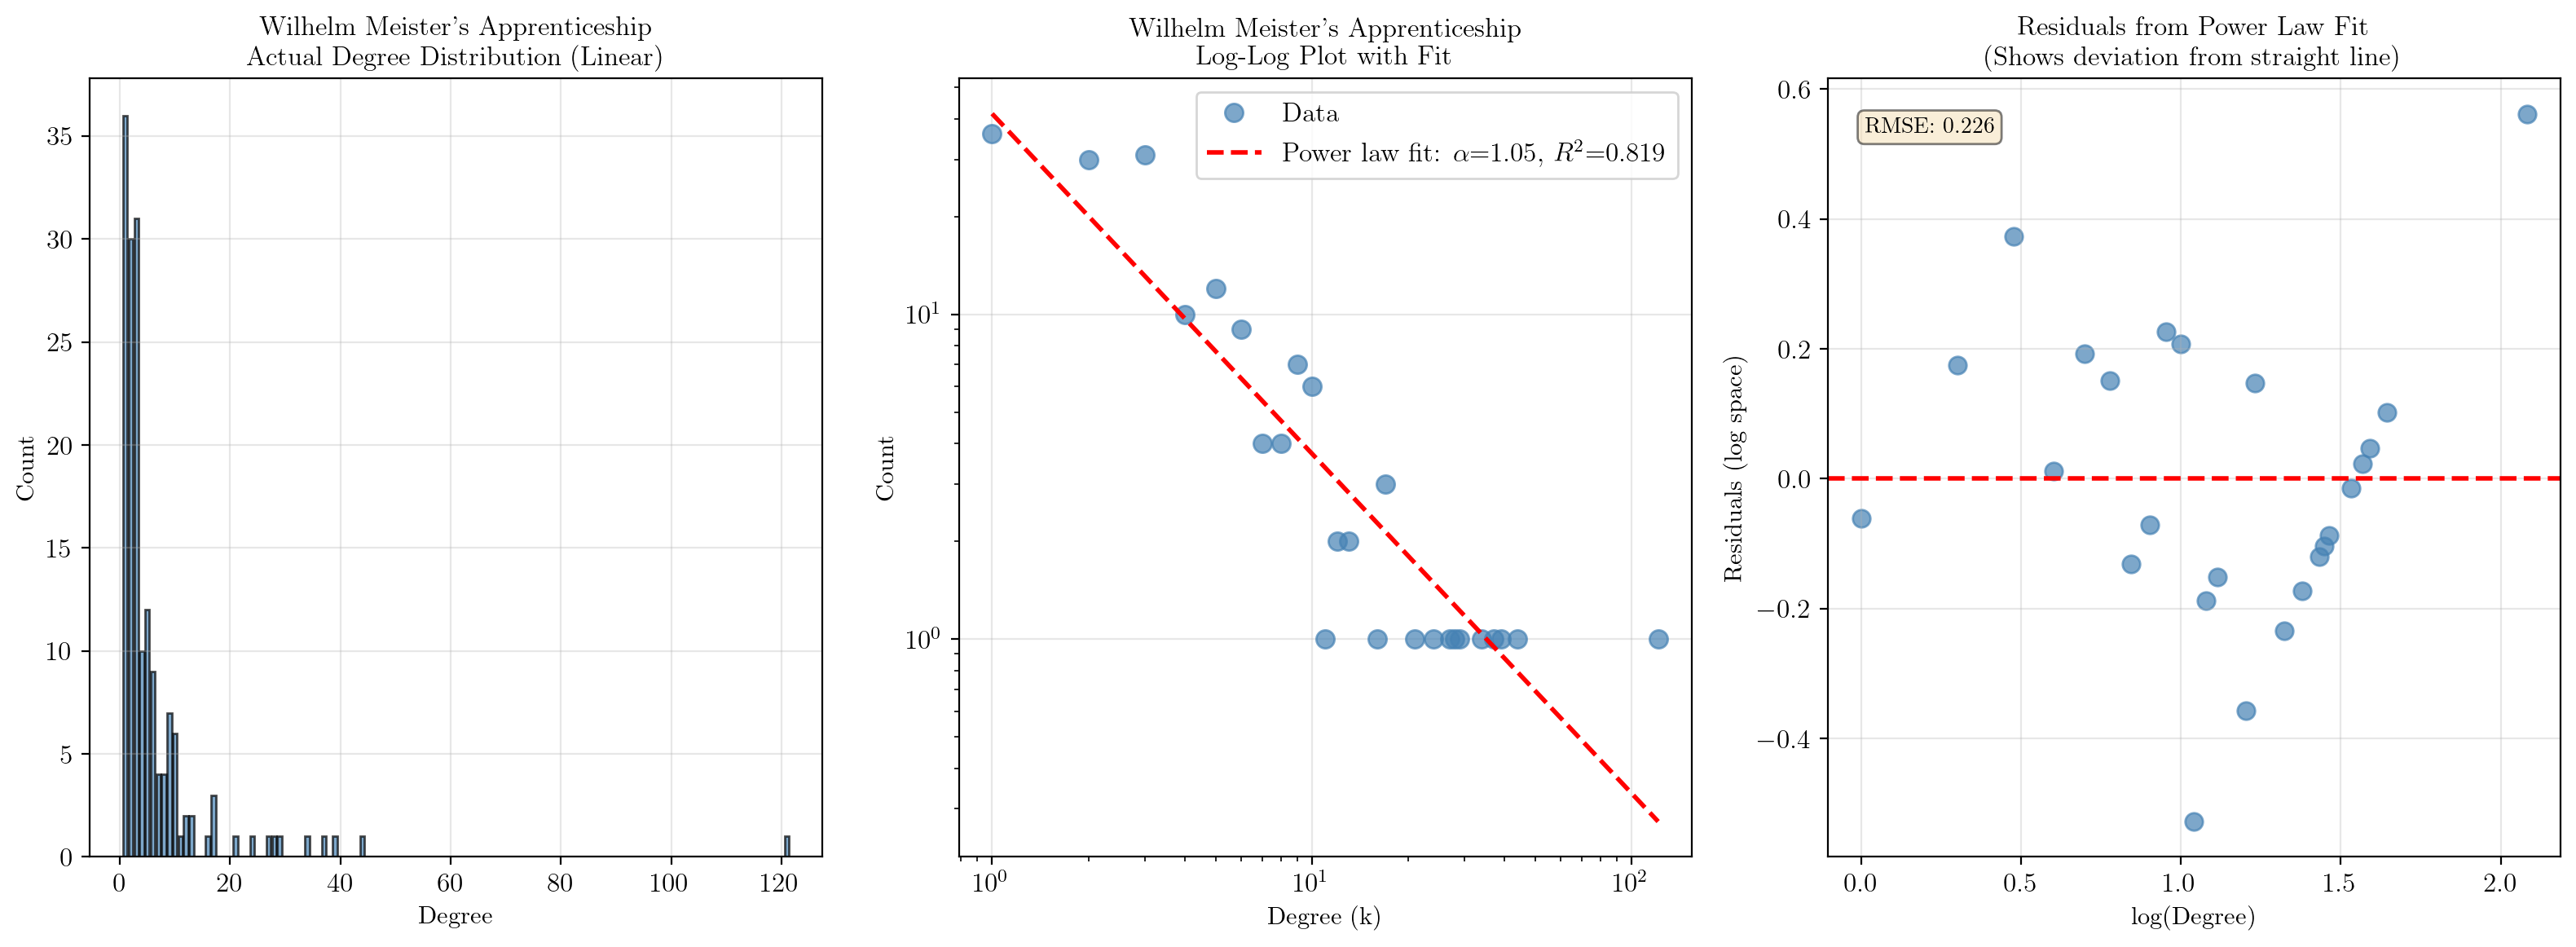

In [18]:
# Test on Jane Eyre
G = load_character_network("../wilhelm/wilhelm_meisters", network_type='total')

# Keep only largest connected component
if not nx.is_connected(G):
    largest_cc = max(nx.connected_components(G), key=len)
    G = G.subgraph(largest_cc).copy()

results = power_law_analysis(G, "Wilhelm Meister's Apprenticeship")


POWER LAW FIT DIAGNOSTICS: Pride and Prejudice

powerlaw library fit:
  alpha = 1.357
  xmin = 1.0
  KS distance = 0.2737

Manual log-log regression:
  alpha = 0.666
  R-squared = 0.6919
  p-value = 0.000000

Model comparison (powerlaw library):
  Power law vs Exponential:
    Log-likelihood ratio: -58.332
    p-value: 0.000000
    → Exponential significantly better


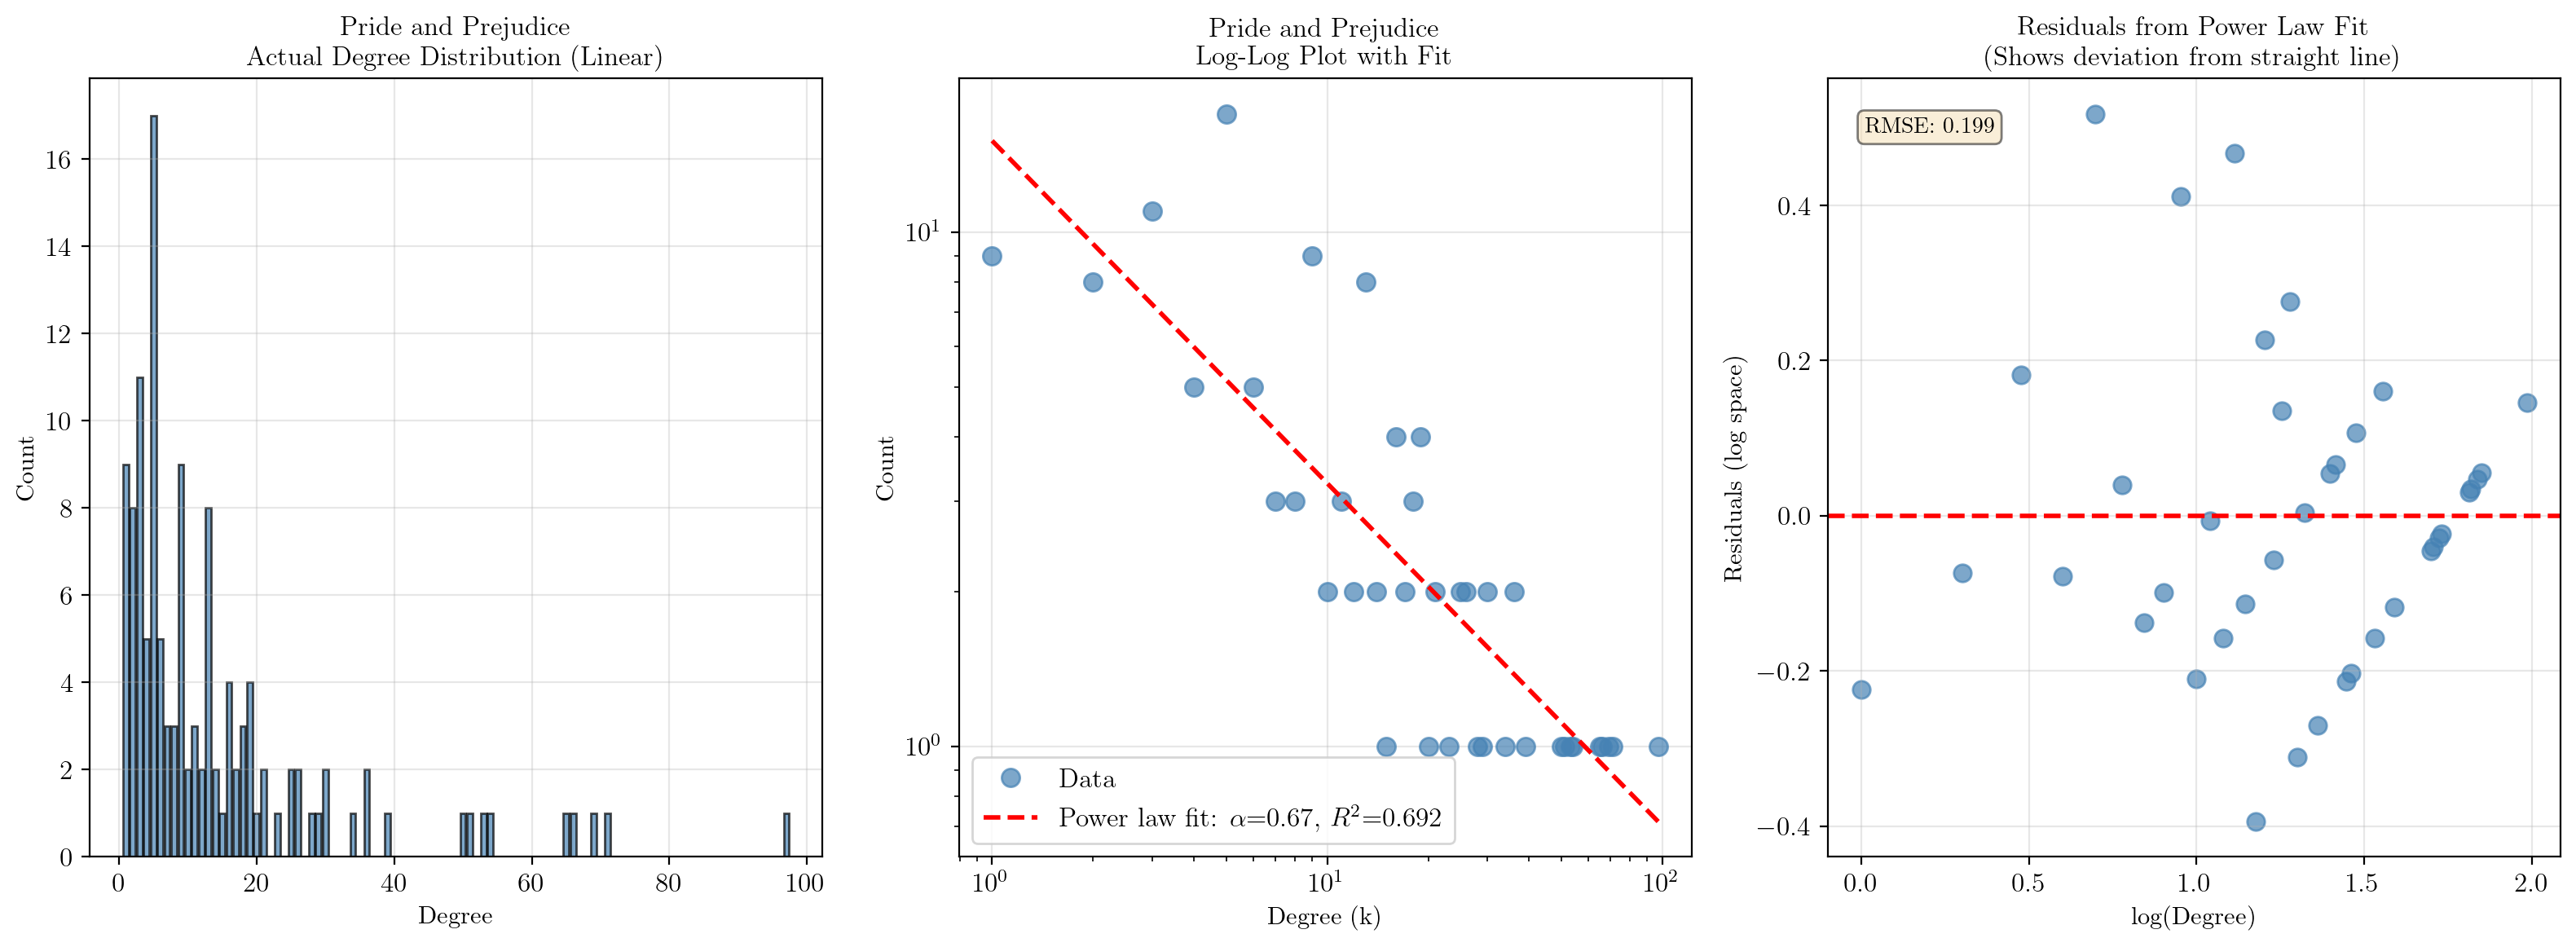

In [19]:
# Test on Jane Eyre
G = load_character_network("../results/output/pride", network_type='total')

# Keep only largest connected component
if not nx.is_connected(G):
    largest_cc = max(nx.connected_components(G), key=len)
    G = G.subgraph(largest_cc).copy()

results = power_law_analysis(G, "Pride and Prejudice")